In [ ]:
import pandas as pd
import re
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score
from scipy.stats import binomtest
import numpy as np

# Read the CSV file into a pandas DataFrame
df = pd.read_csv("ColetaSPIRA_RECENTE-clean.csv")
print(f"Tamanho do dataset: {df.shape}")

Tamanho do dataset: (1113, 49)


In [ ]:
def filtrar_testes(df):
  # Preenche valores NaN na coluna 'local_coleta' com string vazia para evitar erros
  # e então filtra as linhas que contêm 'TESTE' (case-insensitive)
  df_filtrado = df[~df['local_coleta'].fillna('').str.contains('TESTE', case=False, na=False)]
  df_filtrado = df_filtrado[~df_filtrado['local_coleta'].fillna('').str.contains('TESTJAQUELINE', case=False, na=False)]
  df_filtrado = df_filtrado[~df_filtrado['local_coleta'].fillna('').str.contains('MARCELO', case=False, na=False)]
  df_filtrado = df_filtrado[~df_filtrado['local_coleta'].fillna('').str.contains('TEST', case=False, na=False)]
  #df_filtrado = df_filtrado[~df_filtrado['local_coleta'].fillna('').str.contains('TESTE', case=False, na=False)]
  df_filtrado = df_filtrado[~df_filtrado['local_coleta'].fillna('').str.contains('HOME', case=False, na=False)]
  return df_filtrado


In [ ]:
print(df['local_coleta'].value_counts())

local_coleta
HC                  691
BP                  112
HCRP                 73
INCOR                42
BPUTI                28
                   ... 
TESTE2HSPE            1
TESTEHSPE             1
TESTERELIGAMENTO      1
HOME                  1
MARCELO               1
Name: count, Length: 77, dtype: int64


In [ ]:
df_filtrado = filtrar_testes(df)
print(f"Shape do DataFrame original: {df.shape}")
print(f"Shape do DataFrame após filtrar testes: {df_filtrado.shape}")
df = df_filtrado

Shape do DataFrame original: (1113, 49)
Shape do DataFrame após filtrar testes: (1042, 49)


In [ ]:
print(df['local_coleta'].value_counts())

local_coleta
HC                 691
BP                 112
HCRP                73
INCOR               42
BPUTI               28
INCORCONV           23
UTIBP               17
HSPE                10
RUA                  9
HCCONTROLE           8
HC-DPV               5
CONV                 4
HC-DPV-1             3
HC-DPV?              2
IAMSPE               2
FM                   2
HC-CONTROLE          2
HC-DPV?-1            1
BPMIRANTE            1
INCOR@SPIRA.COM      1
CONTROLEHC           1
CONTROLE             1
INCORLAB             1
UNIMAR               1
HCFMUSP              1
HOSPITALBP           1
Name: count, dtype: int64


In [ ]:
def analisar_coluna(df, coluna):
  lista = []
  for linha in df[coluna]:
    if not pd.isna(linha):
      lista.append(linha.lower())
  return lista

lista_comorb = analisar_coluna(df, 'outras_comorbidades')
len(lista_comorb)

498

In [ ]:
def gerar_lista_comorbidades(lista, seps):
  nova_lista = []
  for item in lista:
    quebrada = [p for p in re.split(seps, item) if p]
    for subitem in quebrada:
      if subitem.strip() not in nova_lista:
        nova_lista.append(subitem.strip())
  return nova_lista

lista_total_comorb = gerar_lista_comorbidades(lista_comorb, r'\s*(?:,|\.|/|\be\b)\s*')
print(len(lista_total_comorb))

266


In [ ]:
print(df['tipo_fumante'].value_counts())


tipo_fumante
Não fumante    694
Ex-fumante     238
Fumante        110
Name: count, dtype: int64


In [ ]:
print(df['nome_sexo'].value_counts())

nome_sexo
Feminino     753
Masculino    289
Name: count, dtype: int64


In [ ]:
print(df['nome_linha_estudo'].value_counts())

nome_linha_estudo
Asma                          533
Controle                      254
Insuficiência Respiratória    172
Tabagismo                      71
Parkinson                      12
Name: count, dtype: int64


In [ ]:
lista_comorb = analisar_coluna(df, 'comorbidades')
len(lista_comorb)

837

In [ ]:
lista_dif_comorb = gerar_lista_comorbidades(lista_comorb, r';')
print(len(lista_dif_comorb))
print(lista_dif_comorb)

14
['rinite', 'refluxo gastroesofágico', 'hipertensão arterial', 'disfunção de prega vogal', 'obesidade', 'distúrbios do sono', 'dpoc', 'diabetes não-insulino dependente', 'doença coronariana', 'dislipidemia', 'doença tireoide', 'infarto agudo do miocárdio', 'insuficiência cardíaca', 'asma brônquica']


In [ ]:
def gerar_rotulos(linha_pesquisa):
  if linha_pesquisa == "Controle":
    return 0
  elif linha_pesquisa == "Asma":
    return 1
  elif linha_pesquisa == "Insuficiência Respiratória":
    return 2
  elif linha_pesquisa == "Tabagismo":
    return 3
  elif linha_pesquisa == "Parkinson":
    return 4
  else:
    assert True == False, "Linha de pesquisa desconhecida"

In [ ]:

def gerar_dataset(df, lista_comorb, tipo="basico"):
  #print("Estou dentro do gerar_dataset: ", len(lista_comorb))
  X, Y = [], []
  if tipo == "basico":
    tamanho = 14
  elif tipo == "sexo":
    tamanho = 16
  elif tipo == "biodados":
    tamanho = 18
  for idx,linha in df.iterrows():
    x = [0]*tamanho
    if tipo == "sexo" or tipo == "biodados":
      if linha['nome_sexo'] == "Masculino":
        x[14] = 1
      else:
        x[15] = 1
    if tipo == "biodados":
      x[16] = linha['peso']
      x[17] = linha['altura']
    comorbidades = linha['comorbidades']
    if pd.isna(comorbidades):
      y = gerar_rotulos(linha['nome_linha_estudo'])
      X.append(x)
      Y.append(y)
    else:
      for comorb in comorbidades.split(';'):
        indice = lista_comorb.index(comorb.strip().lower())
        x[indice] = 1
      y = gerar_rotulos(linha['nome_linha_estudo'])
      X.append(x)
      Y.append(y)
  assert len(X) == len(Y)
  return X,Y


def contar_um(lista):
  contador = 0
  for item in lista:
    if item == 1:
      contador += 1
  return contador/len(lista)

In [ ]:
def filtrar_dataset(X, Y, indices_selecionar):
  X_filtrado, Y_filtrado, outro_X, outro_Y = [], [], [], []
  for x,y in zip(X,Y):
    if y in indices_selecionar:
      X_filtrado.append(x)
      Y_filtrado.append(y)
    else:
      outro_X.append(x)
      outro_Y.append(y)
  return X_filtrado, Y_filtrado, outro_X, outro_Y

def renomear_Y(Y, dic):
  for i in range(len(Y)):
    if Y[i] in dic:
      Y[i] = dic[Y[i]]

def get_model(nome):
  if nome == "LinearRegressor":
    return LinearRegression()
  elif nome == "RandomForestRegressor":
    return RandomForestRegressor()
  elif nome == "RandomForestClassifier":
    return RandomForestClassifier()
  else:
    assert True == False, "Modelo desconhecido"




def treinar_e_avaliar_modelo(X, Y, nome_modelo):
  performance_acc, performance_kappa, binomial_result = [], [], []
  for i in range(100):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)
    model = get_model(nome_modelo)
    model.fit(X_train, Y_train)
    # Make predictions on the test data
    Y_pred_continuous = model.predict(X_test)
    # Apply a threshold of 0.5 to convert continuous predictions to binary (0 or 1)
    Y_pred_binary = (Y_pred_continuous >= 0.5).astype(int)
    # Compare with Y_test and calculate accuracy
    prop_1 = contar_um(Y_test)
    prop_0 = 1-prop_1
    coeficiente_binomial = prop_1**2 + prop_0**2
    #print(f"O número de verdadeiros no test set: {prop_1:.4f}")
    accuracy = accuracy_score(Y_test, Y_pred_binary)
    n = len(Y_test)
    k = round(n*accuracy)
    result = binomtest(k, n, p=coeficiente_binomial, alternative="greater")
    if result.pvalue < 0.05:
      binomial_result.append(True)
    else:
      binomial_result.append(False)
    kappa = cohen_kappa_score(Y_test, Y_pred_binary)
    performance_acc.append(accuracy)
    performance_kappa.append(kappa)
  return performance_acc, performance_kappa, binomial_result, model

In [ ]:
def somar_colunas(X):
  colunas = [0]*(X.shape[1]+1)
  for linha in X:
    for i in range(len(linha)):
      colunas[i] += linha[i]
  for i in range(len(colunas)):
    print(f"Linha {i}: {colunas[i]}")


In [ ]:
X, Y = gerar_dataset(df, lista_dif_comorb, tipo="basico")
labels_selecionados = [2,3]
X, Y, outro_X, outro_Y = filtrar_dataset(X, Y, labels_selecionados)
nome_modelo = "LinearRegressor"
renomear_Y(Y, {labels_selecionados[0]:0, labels_selecionados[1]:1})
print("Tamanho do dataset: ", len(X))
X = np.array(X)
print(X.shape)
Y = np.array(Y)
somar_colunas(X)

Tamanho do dataset:  243
(243, 14)
Linha 0: 1
Linha 1: 7
Linha 2: 98
Linha 3: 9
Linha 4: 17
Linha 5: 8
Linha 6: 15
Linha 7: 3
Linha 8: 4
Linha 9: 10
Linha 10: 3
Linha 11: 1
Linha 12: 1
Linha 13: 1
Linha 14: 0


In [ ]:
performance_acc, performance_kappa, binomial_result, model = treinar_e_avaliar_modelo(X, Y, nome_modelo)
print(f"Média de acc: {np.mean(performance_acc)} e desvio padrão: {np.std(performance_acc)} ")
print(f"Média de kappa: {np.mean(performance_kappa)} e desvio padrão: {np.std(performance_kappa)} ")
print(f"Vezes que deu o binomial: {sum(binomial_result)/len(binomial_result)}")

Média de acc: 0.8208163265306123 e desvio padrão: 0.03791526974891881 
Média de kappa: 0.4694681204551739 e desvio padrão: 0.13182693464103243 
Vezes que deu o binomial: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix

def avaliar_modelo_outro_split(X, Y, model):
  Y_pred_continuous = model.predict(X)
  # Apply a threshold of 0.5 to convert continuous predictions to binary (0 or 1)
  Y_pred_binary = (Y_pred_continuous >= 0.5).astype(int)
  conf_matrix = confusion_matrix(Y, Y_pred_binary, labels=[0,1,2,3,4], normalize='true')
  print("Confusion Matrix:")
  print(conf_matrix)

avaliar_modelo_outro_split(outro_X, outro_Y, model)

Confusion Matrix:
[[0.47244094 0.52755906 0.         0.         0.        ]
 [0.10318949 0.89681051 0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         1.         0.         0.         0.        ]]


In [ ]:


# Assuming Y and Y_pred_binary are already defined from previous steps
# If they are not defined in the current scope, you might need to run the previous cells.

# Create the confusion matrix


NameError: name 'Y_pred_binary' is not defined

In [ ]:
import matplotlib.pyplot as plt

def plotar_imagem(performance_acc):
  iterations = range(1, len(performance_acc) + 1)
  print(iterations)
  cumulative_mean_acc = [np.mean(performance_acc[:i]) for i in iterations]
  cumulative_std_acc = [np.std(performance_acc[:i]) for i in iterations]

  plt.figure(figsize=(10, 6))
  plt.plot(iterations, cumulative_mean_acc, label='Média Cumulativa de Accuracy', color='blue')
  plt.fill_between(
      iterations,
      np.array(cumulative_mean_acc) - np.array(cumulative_std_acc),
      np.array(cumulative_mean_acc) + np.array(cumulative_std_acc),
      color='red', alpha=0.2, label='Desvio Padrão Cumulativo (Área)'
  )
  plt.xlabel('Iteração (Época)')
  plt.ylabel('Valor')
  plt.title('Média e Desvio Padrão Cumulativo de Accuracy ao Longo das Iterações')
  plt.legend()
  plt.grid(True)
  plt.show()

Daqui em diante vai ser usando rede neural

In [ ]:
import matplotlib.pyplot as plt

def plotar_grafico_linha(valores,valores2, titulo="Gráfico de Linha", x_label="Índice", y_label="Valor"):
  """
  Gera um gráfico de linha a partir de uma lista de valores.

  Args:
    valores (list or array): A lista de valores a serem plotados.
    titulo (str): O título do gráfico (padrão: 'Gráfico de Linha').
    x_label (str): O rótulo do eixo X (padrão: 'Índice').
    y_label (str): O rótulo do eixo Y (padrão: 'Valor').
  """
  plt.figure(figsize=(10, 6))
  plt.plot(valores, marker='o', linestyle='-', color='blue')
  plt.plot(valores2, marker='o', linestyle='-', color='red')
  plt.title(titulo)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.grid(True)
  plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Neural Network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # Input layer to hidden layer
        self.relu = nn.ReLU()                          # Activation function
        self.fc2 = nn.Linear(hidden_size, output_size) # Hidden layer to output layer
        self.sigmoid = nn.Sigmoid()                    # Sigmoid for binary classification

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# Assuming X is already defined and is a numpy array
# Convert X to a PyTorch tensor to get its shape for input_size
# input_tensor = torch.from_numpy(X).float()
# input_size = input_tensor.shape[1] # Number of features in X (which is 27)
# hidden_size = 23 # As requested by the user
# output_size = 1 # As requested by the user

# # Instantiate the model
# model = NeuralNetwork(input_size, hidden_size, output_size)

# # Print the model architecture
# print(model)


NeuralNetwork(
  (fc1): Linear(in_features=27, out_features=23, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=23, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
def test_acc_model(Y_hat, Y):
  discretized_outputs = (Y_hat >= 0.5).float()
  # Compare with the Y_tensor and count where they are equal
  matches = (discretized_outputs == Y).sum().item()
  total_elements = Y.numel()
  #print(f"Número de correspondências: {matches}")
  #print(f"Número total de elementos: {total_elements}")
  acc = matches / total_elements * 100
  #print(f"Porcentagem de correspondências (Accuracy): {acc:.2f}%")
  return acc

def train_model(model, X_data, Y_data, X_teste, Y_teste, epochs=10):
  # Convert numpy arrays to PyTorch tensors
  acc_treino, acc_teste = [], []
  X_tensor = torch.from_numpy(X_data).float()
  Y_tensor = torch.from_numpy(Y_data).float().view(-1, 1) # Reshape Y to (N, 1) for MSE loss
  X_teste_tensor = torch.from_numpy(X_teste).float()
  Y_teste_tensor = torch.from_numpy(Y_teste).float().view(-1, 1) # Reshape Y to (N, 1) for MSE loss
  # Define Loss and Optimizer
  criterion = nn.MSELoss() # Mean Squared Error Loss
  optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate
  optimizer.zero_grad() # Clear gradients
  with torch.no_grad():
    outputs = model(X_tensor)
    acc = test_acc_model(outputs, Y_tensor)
    acc_treino.append(acc)
    outputs2 = model(X_teste_tensor)
    acc = test_acc_model(outputs2, Y_teste_tensor)
    acc_teste.append(acc)
  optimizer.zero_grad() # Clear gradients
  #print("Starting model training...")
  for epoch in range(epochs):
    # Forward pass
    outputs = model(X_tensor)
    #print(outputs.shape)
    #print(Y_tensor.shape)
    loss = criterion(outputs, Y_tensor)
    # Backward and optimize
    loss.backward()       # Backpropagation
    optimizer.step()      # Update weights
    with torch.no_grad():
      outputs = model(X_tensor)
      acc = test_acc_model(outputs, Y_tensor)
      acc_treino.append(acc)
      outputs2 = model(X_teste_tensor)
      acc = test_acc_model(outputs2, Y_teste_tensor)
      acc_teste.append(acc)
    optimizer.zero_grad() # Clear gradients
    # if (epoch + 1) % 10 == 0: # Print loss every epoch
    #   print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
  #print("Training complete!")
  return acc_treino, acc_teste



In [ ]:
perf_test = []
for i in range(100):
  X, Y = gerar_dataset(df, lista_dif_comorb, tipo="basico")
  X, Y = filtrar_dataset(X, Y, 4)
  renomear_Y(Y)
  #print("Tamanho do dataset: ", len(X))
  X = np.array(X)
  #print(X.shape)
  Y = np.array(Y)

  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)
  input_tensor = torch.from_numpy(X_train).float()
  input_size = input_tensor.shape[1] # Number of features in X (which is 27)
  hidden_size = input_size # As requested by the user
  output_size = 1 # As requested by the user

  # Instantiate the model
  model = NeuralNetwork(input_size, hidden_size, output_size)
  treino, teste = train_model(model, X_train, Y_train, X_test, Y_test, epochs=3000)
  perf_test.append(teste[-1])
print(f"Média de acc: {np.mean(perf_test)} e desvio padrão: {np.std(perf_test)} ")

Média de acc: 95.87037037037032 e desvio padrão: 1.4781211890968402 


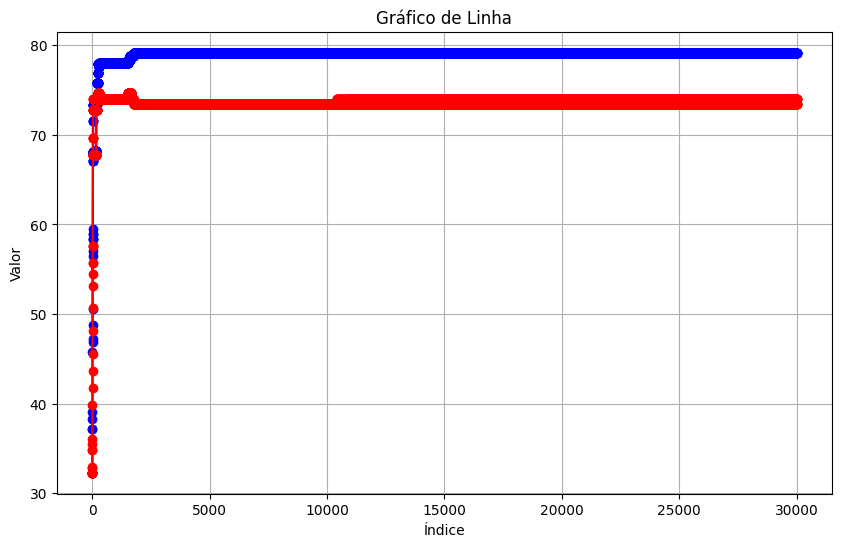

In [ ]:
plotar_grafico_linha(treino, teste)

In [ ]:
teste[-1]

79.11392405063292